# 01 — Exploratory Data Analysis
**Goal:** Understand the shape, size, and content of the raw Medicaid dataset before any cleaning.

**Key Questions:**
- How many rows and columns are there?
- What are the data types?
- What is the date range?
- How many unique providers and HCPCS codes exist?
- What does the spending distribution look like?

In [1]:
import duckdb
import polars as pl
import os
import numpy as np
import pandas as pd
import datetime


con = duckdb.connect()
parquet_path = "~/Downloads/medicaid-provider-spending.parquet"
con.execute(f"CREATE VIEW medicaid AS SELECT * FROM read_parquet('{parquet_path}')")


Let's take a peek at how the data looks


In [2]:
## First 20 Rows
con.sql("select * from medicaid limit 20")


┌──────────────────────────┬────────────────────────────┬────────────┬──────────────────┬────────────────────────────┬──────────────┬──────────────┐
│ BILLING_PROVIDER_NPI_NUM │ SERVICING_PROVIDER_NPI_NUM │ HCPCS_CODE │ CLAIM_FROM_MONTH │ TOTAL_UNIQUE_BENEFICIARIES │ TOTAL_CLAIMS │  TOTAL_PAID  │
│         varchar          │          varchar           │  varchar   │     varchar      │           int64            │    int64     │    double    │
├──────────────────────────┼────────────────────────────┼────────────┼──────────────────┼────────────────────────────┼──────────────┼──────────────┤
│ 1376609297               │ 1376609297                 │ T1019      │ 2024-07          │                      39765 │      1205701 │ 118887675.31 │
│ 1376609297               │ 1376609297                 │ T1019      │ 2024-08          │                      39677 │      1152534 │ 115561066.11 │
│ 1376609297               │ 1376609297                 │ T1019      │ 2024-05          │                 

In [3]:
con.sql("DESCRIBE medicaid")


┌────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│        column_name         │ column_type │  null   │   key   │ default │  extra  │
│          varchar           │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ BILLING_PROVIDER_NPI_NUM   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ SERVICING_PROVIDER_NPI_NUM │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ HCPCS_CODE                 │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ CLAIM_FROM_MONTH           │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ TOTAL_UNIQUE_BENEFICIARIES │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ TOTAL_CLAIMS               │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ TOTAL_PAID                 │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
└────────────────────────────┴─────────────┴─────────┴─────────┴─

In [4]:
con.sql("SUMMARIZE medicaid")

┌────────────────────────────┬─────────────┬────────────┬──────────────┬───────────────┬───────────────────┬────────────────────┬───────────────────┬───────────────────┬────────────────────┬───────────┬─────────────────┐
│        column_name         │ column_type │    min     │     max      │ approx_unique │        avg        │        std         │        q25        │        q50        │        q75         │   count   │ null_percentage │
│          varchar           │   varchar   │  varchar   │   varchar    │     int64     │      varchar      │      varchar       │      varchar      │      varchar      │      varchar       │   int64   │  decimal(9,2)   │
├────────────────────────────┼─────────────┼────────────┼──────────────┼───────────────┼───────────────────┼────────────────────┼───────────────────┼───────────────────┼────────────────────┼───────────┼─────────────────┤
│ BILLING_PROVIDER_NPI_NUM   │ VARCHAR     │ 0          │ SD07819990   │        712549 │ NULL              │ NULL   

4% of rows are missing a Servicing Provider NPI. For now we won't worry about these missing values. A billing NPI is most important.

Interesting also to see some negative values for Total Paid. This could be due to adjustments or refunds.

In [5]:
result = con.sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(SERVICING_PROVIDER_NPI_NUM) AS has_servicing,
    COUNT(*) - COUNT(SERVICING_PROVIDER_NPI_NUM) AS no_servicing,
    COUNT_IF(SERVICING_PROVIDER_NPI_NUM <> BILLING_PROVIDER_NPI_NUM) AS servicing_differs_from_billing,
    COUNT_IF(SERVICING_PROVIDER_NPI_NUM = BILLING_PROVIDER_NPI_NUM) AS servicing_same_as_billing,
FROM medicaid
""").to_df()

In [6]:
total = result["total_rows"].iloc[0]

result.T.rename(columns={0: "count"}).assign(
    pct=lambda df: (df["count"] / total * 100).round(2).astype(str) + "%"
).style.format({"count": "{:,}"})


,count,pct
total_rows,"227,083,361.0",100.0%
has_servicing,"217,593,016.0",95.82%
no_servicing,"9,490,345.0",4.18%
servicing_differs_from_billing,"147,861,529.0",65.11%
servicing_same_as_billing,"69,731,487.0",30.71%


Around 67% of rows have different billing and servicing providers. This makes sense as hospitals and clinics often bill for services provided by individual doctors or other healthcare professionals. We can however investigate this further to see if there are any patterns in the data, such as certain types of providers or services that are more likely to have different billing and servicing providers, and checking to see if the average total paid differs between rows with the same or different billing and servicing providers. For now, we will just note this as an interesting observation and move on to the next steps of our analysis.

In [7]:
totals = con.sql("""
    SELECT count(*) as total_rows, 
    sum(TOTAL_PAID) as total_paid,
    sum(TOTAL_CLAIMS) as total_claims,
    sum(TOTAL_UNIQUE_BENEFICIARIES) as total_encounters
    -- technically not correct to sum TOTAL_UNIQUE_BENEFICIARIES as someone may appear 
    -- multiple times in a dataset but since we aren't doing anything with the number we will just sum it and leave it for now  
    from medicaid
    
""").to_df()


In [8]:
totals

,total_rows,total_paid,total_claims,total_encounters
0,227083361,1.093563e+12,1.882556e+10,1.131796e+10


1.09 Trillion paid out, 18 billion claims, and 11 billion total beneficiaries in total across 2018-2024.

In [9]:
total_days = (datetime.date(2024, 12, 31) - datetime.date(2018, 1, 1)).days


spend_per_day = totals["total_paid"].item() / total_days
claims_per_day = totals["total_claims"].item() / total_days


print(f"Roughly  ${round(spend_per_day, 2)} is spent per day")
print(f"There are roughly {round(claims_per_day, 2)} claims per day ")

Roughly  $427841484.16 is spent per day
There are roughly 7365244.14 claims per day 


### Data Shape

In [10]:
con.sql("""
    SELECT
        COUNT(*)                        AS total_rows,
        COUNT(DISTINCT HCPCS_CODE)      AS unique_hcpcs,
        COUNT(DISTINCT BILLING_PROVIDER_NPI_NUM) AS unique_billing_providers,
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS unique_servicing_providers,
        MIN(CLAIM_FROM_MONTH)           AS earliest_month,
        MAX(CLAIM_FROM_MONTH)           AS latest_month
    FROM medicaid
""").pl()

total_rows,unique_hcpcs,unique_billing_providers,unique_servicing_providers,earliest_month,latest_month
i64,i64,i64,i64,str,str
227083361,10881,617503,1627362,"""2018-01""","""2024-12"""


#### Data Shape
##### 227 million rows, 10881 unique billing codes, 617k unique billing providers, 1.6 million unique servicing provider. The date range is from January 2018 to December 2024 (as expected).

## 3. Spending Distribution

In [11]:
con.sql("""
    SELECT
        MIN(TOTAL_PAID)    AS min_paid,
        MAX(TOTAL_PAID)    AS max_paid,
        AVG(TOTAL_PAID)    AS avg_paid,
        MEDIAN(TOTAL_PAID) AS median_paid,
        SUM(TOTAL_PAID)    AS total_paid
    FROM medicaid
""").pl()

min_paid,max_paid,avg_paid,median_paid,total_paid
f64,f64,f64,f64,f64
-183021.84,1.1889e8,4815.688955,616.39,1.0936e12


In [12]:
## Let's check how many negatives there are
## We shouldn't remove negatives as they represent claim reversals
## and they ultimately represent net medicaid spend

con.sql("""
    SELECT 
        SUM(TOTAL_PAID),
        COUNT(TOTAL_PAID),
        SUM(TOTAL_PAID) / COUNT(TOTAL_PAID) as avg_reversal
    FROM medicaid
    WHERE TOTAL_PAID < 0
""")


┌────────────────────┬───────────────────┬────────────────────┐
│  sum(TOTAL_PAID)   │ count(TOTAL_PAID) │    avg_reversal    │
│       double       │       int64       │       double       │
├────────────────────┼───────────────────┼────────────────────┤
│ -8360301.790000003 │              9239 │ -904.8924981058559 │
└────────────────────┴───────────────────┴────────────────────┘

Only a small amount, roughly 8.3 million out of trillion dollars and only 9239 out of 227 million claims. We can ignore these outliers for now. We won't remove them but we will keep in mind that they exist and may want to investigate them further in the future.


## 4. HCPCS Codes by Volume

In [13]:
con.sql("SELECT COUNT(DISTINCT HCPCS_CODE) FROM medicaid")

┌────────────────────────────┐
│ count(DISTINCT HCPCS_CODE) │
│           int64            │
├────────────────────────────┤
│                      10881 │
└────────────────────────────┘

In [14]:
# Aggregate by procedure code: provider count, claim volume, and total spend — 
# sorted by most common codes first

hcpcs = con.sql("""
    SELECT HCPCS_CODE, COUNT(*) AS row_count, SUM(TOTAL_CLAIMS) as total_claims, SUM(TOTAL_PAID) AS total_paid
    FROM medicaid
    GROUP BY HCPCS_CODE
    ORDER BY row_count DESC
""").pl()
hcpcs.head(10)

HCPCS_CODE,row_count,total_claims,total_paid
str,i64,"decimal[38,0]",f64
"""99213""",13566914,764306590,3.3003e10
"""99214""",11728025,502480931,2.9914e10
"""99284""",3980198,170705529,2.0152e10
"""99283""",3270001,157926994,1.6875e10
"""99285""",2901462,111002396,1.5097e10
"""36415""",2730219,224973443,9.3579e8
"""T1015""",2429393,322233922,4.9153e10
"""D0120""",2280791,136235319,3.8150e9
"""85025""",2259404,276124130,1.2682e9


In [35]:
totals

,total_rows,total_paid,total_claims,total_encounters
0,227083361,1.093563e+12,1.882556e+10,1.131796e+10


In [20]:
# sanity check
totals
print(f"{hcpcs["row_count"].sum() == totals.iloc[0,0]}")
print(f"{hcpcs["total_claims"].sum() == totals.iloc[0,2]}")
print(f"{hcpcs["total_paid"].sum() == totals.iloc[0,1]}")


True
True
False


In [21]:
totals.iloc[0,1] - hcpcs["total_paid"].sum()

np.float64(1.2685546875)

Off by .61 dollars. I think it may be due to rounding errors. We can continue

In [22]:
hcpcs_sorted_by_paid = hcpcs.sort("total_paid", descending=True)
print(hcpcs_sorted_by_paid.head(10)["total_paid"].sum())
print(hcpcs_sorted_by_paid.head(10)["total_paid"].sum() / totals.iloc[0,1])



374301169679.38947
0.34227678392903677


34% of total paid comes from the same 10 claim codes
Let's investigate this a little more

In [23]:
hcpcs_sorted_by_paid

HCPCS_CODE,row_count,total_claims,total_paid
str,i64,"decimal[38,0]",f64
"""T1019""",457916,1100608370,1.2274e11
"""T1015""",2429393,322233922,4.9153e10
"""T2016""",81288,69000080,3.4905e10
"""99213""",13566914,764306590,3.3003e10
"""S5125""",214380,398071209,3.1342e10
…,…,…,…
"""0172""",1,15,0.0
"""A9531""",1,14,0.0
"""T1099""",1,18,0.0


In [38]:
hcpcs_sorted_by_paid = hcpcs_sorted_by_paid.with_columns([
    (pl.col("total_paid").cum_sum() / pl.col("total_paid").sum()).alias("cumulative_share"),
])

hcpcs_spend_thresholds = hcpcs_sorted_by_paid.clone()

threshold_codes = {}
for threshold in [.25 ,.5, .8, .90, .95, .99]:
    n = (hcpcs_spend_thresholds["cumulative_share"] <= threshold).sum() + 1
    codes = hcpcs_spend_thresholds.head(n)["HCPCS_CODE"].to_list()
    threshold_codes[threshold] = codes
    print(
        f"{threshold:.0%} of total spend covered by top {n} codes ({n / len(hcpcs_spend_thresholds):.1%} of all codes)"
    )





25% of total spend covered by top 6 codes (0.1% of all codes)
50% of total spend covered by top 32 codes (0.3% of all codes)
80% of total spend covered by top 177 codes (1.6% of all codes)
90% of total spend covered by top 375 codes (3.4% of all codes)
95% of total spend covered by top 687 codes (6.3% of all codes)
99% of total spend covered by top 1780 codes (16.4% of all codes)


In [26]:
total_spend = hcpcs_sorted_by_paid["total_paid"].sum()

hcpcs_sorted_by_paid = hcpcs_sorted_by_paid.with_columns(
    (pl.col("total_paid") / total_spend).alias("Spend %") * 100,
    (pl.col("total_paid") / pl.col("total_claims").cast(pl.Float64)).alias("avg_per_claim")

)
top_10 = hcpcs_sorted_by_paid.head(n=10)['HCPCS_CODE'].to_list()
hcpcs_sorted_by_paid.head(n=10)

HCPCS_CODE,row_count,total_claims,total_paid,cumulative_share,Spend %,avg_per_claim
str,i64,"decimal[38,0]",f64,f64,f64,f64
"""T1019""",457916,1100608370,1.2274e11,0.112238,11.223822,111.519729
"""T1015""",2429393,322233922,4.9153e10,0.157185,4.494727,152.537226
"""T2016""",81288,69000080,3.4905e10,0.189104,3.191855,505.868062
"""99213""",13566914,764306590,3.3003e10,0.219283,3.017918,43.18009
"""S5125""",214380,398071209,3.1342e10,0.247944,2.866062,78.735123
"""99214""",11728025,502480931,2.9914e10,0.275298,2.735449,59.532325
"""99284""",3980198,170705529,2.0152e10,0.293726,1.842764,118.049976
"""H2016""",72289,60739036,1.9748e10,0.311784,1.805821,325.125208
"""99283""",3270001,157926994,1.6875e10,0.327215,1.543121,106.853151


T1019 alone accounts for 11% of total paid. This code is for " Personal care services, per 15 minutes, not for an inpatient or resident of a hospital, nursing facility, ICF/MR or IMD, part of the individualized plan of treatment (code may not be used to identify services provided by home health aide or certified nurse assistant)". 

Let's investigate the same for codes with the highest volume of claims. 


In [27]:
hcpcs_sorted_by_claims = hcpcs.sort("total_claims", descending=True)
hcpcs_sorted_by_claims = hcpcs_sorted_by_claims.with_columns(
    [(pl.col("total_claims").cast(pl.Float64) / pl.col("total_claims").cast(pl.Float64).sum()).alias("Percentage") * 100]
)
hcpcs_sorted_by_claims.head(n=10)

HCPCS_CODE,row_count,total_claims,total_paid,Percentage
str,i64,"decimal[38,0]",f64,f64
"""T1019""",457916,1100608370,1.2274e11,5.84635
"""99213""",13566914,764306590,3.3003e10,4.05994
"""99214""",11728025,502480931,2.9914e10,2.669141
"""S5125""",214380,398071209,3.1342e10,2.114525
"""T1015""",2429393,322233922,4.9153e10,1.711683
"""H0020""",125637,312323784,6.2536e9,1.659041
"""85025""",2259404,276124130,1.2682e9,1.466751
"""80053""",1664536,226139755,1.9513e9,1.201238
"""36415""",2730219,224973443,9.3579e8,1.195042


T1019 again is the highest volume code, with 5.8% of total claims. Makes sense as it is also the highest paid code.

In [28]:
set(top_10) & set(hcpcs_sorted_by_claims.head(10)["HCPCS_CODE"].to_list())


{'99213', '99214', 'S5125', 'T1015', 'T1019'}

5 codes overlap between the top 10 codes by total paid and top 10 codes by volume. 

In [39]:
hcpcs_sorted_by_claims = hcpcs_sorted_by_claims.with_columns(
    pl.col("total_claims").cast(pl.Float64)
).with_columns([
    (pl.col("total_claims").cum_sum() / pl.col("total_claims").sum()).alias("cumulative_share"),
])


threshold_codes = {}
for threshold in [0.25, 0.50, 0.80, 0.90, 0.95, 0.99]:
    n = (hcpcs_sorted_by_claims["cumulative_share"] <= threshold).sum() + 1
    codes = hcpcs_sorted_by_claims.head(n)["HCPCS_CODE"].to_list()
    threshold_codes[threshold] = codes
    print(
        f"{threshold:.0%} of claims covered by top {n} codes ({n / len(hcpcs_sorted_by_claims):.1%} of all codes)"
    )

hcpcs_sorted_by_claims.select(["HCPCS_CODE", "total_claims","Percentage", "cumulative_share"]).head(10)

25% of claims covered by top 13 codes (0.1% of all codes)
50% of claims covered by top 65 codes (0.6% of all codes)
80% of claims covered by top 294 codes (2.7% of all codes)
90% of claims covered by top 587 codes (5.4% of all codes)
95% of claims covered by top 961 codes (8.8% of all codes)
99% of claims covered by top 2124 codes (19.5% of all codes)


HCPCS_CODE,total_claims,Percentage,cumulative_share
str,f64,f64,f64
"""T1019""",1.1006e9,5.84635,0.058464
"""99213""",7.6430659e8,4.05994,0.099063
"""99214""",5.02480931e8,2.669141,0.125754
"""S5125""",3.98071209e8,2.114525,0.1469
"""T1015""",3.22233922e8,1.711683,0.164016
"""H0020""",3.12323784e8,1.659041,0.180607
"""85025""",2.7612413e8,1.466751,0.195274
"""80053""",2.26139755e8,1.201238,0.207287
"""36415""",2.24973443e8,1.195042,0.219237


Summary Statitstics for the top 10 codes by total paid and top 10 codes by volume.



In [44]:
hcpcs.select([
    pl.col("total_paid").mean().alias("mean_spend"),
    pl.col("total_paid").std().alias("std_spend"),
    pl.col("total_paid").median().alias("median_spend"),

    (pl.col("total_paid").sum()  / pl.col("total_claims").sum()).alias("mean_spend_per_claim")
])


mean_spend,std_spend,median_spend,mean_spend_per_claim
f64,f64,f64,f64
1.0050e8,1.5279e9,197925.6,58.089247


Mean spread and spread per claim are important for different reasons. 

Average spend per code is roughly 100 million dollars. The spread is very large though, as the standard deviation is roughly 1.5 billion dollars. That is incredible and shows how skewed the distribution is. The median is only 197 thousand dollars, which shows that a majority of codes have very low total paid amounts, and a small amount of codes have very high total paid amounts, which is consistent with the fact that only 50% of total paid comes from 32 claim codes.

NPI's

An NPI (National Provider Identifier) is a unique 10-digit identification number assigned to healthcare providers in the United States. It is used to identify healthcare providers in electronic transactions, such as billing and claims processing. 

This will be a preliminary analysis of the NPI's in the dataset. We will look at the distribution of billing and servicing providers, as well as the overlap between the two. Later on, we will use a dataset from the NPI Registry to get more information about the providers, like their names and location.

In [49]:
con.sql("SELECT COUNT (DISTINCT SERVICING_PROVIDER_NPI_NUM) FROM medicaid")

┌────────────────────────────────────────────┐
│ count(DISTINCT SERVICING_PROVIDER_NPI_NUM) │
│                   int64                    │
├────────────────────────────────────────────┤
│                                    1627362 │
└────────────────────────────────────────────┘

In [50]:
con.sql("SELECT COUNT (DISTINCT BILLING_PROVIDER_NPI_NUM) FROM medicaid")

┌──────────────────────────────────────────┐
│ count(DISTINCT BILLING_PROVIDER_NPI_NUM) │
│                  int64                   │
├──────────────────────────────────────────┤
│                                   617503 │
└──────────────────────────────────────────┘

In [ ]:
billing_providers = con.sql(""" 
    SELECT BILLING_PROVIDER_NPI_NUM,
    COUNT(*) as row_count , --- how often it appears in the dataset
    SUM(TOTAL_CLAIMS) as total_claims, 
    SUM(TOTAL_PAID) as total_paid,
    MIN(CLAIM_FROM_MONTH) as first_bill,
    MAX(CLAIM_FROM_MONTH) as last_bill
    FROM MEDICAID
    GROUP BY BILLING_PROVIDER_NPI_NUM
    ORDER BY COUNT(*) DESC
    """).pl()
                
# Min and Max are used to try and gauge for when a billing provider was opened/ closed
# Providers that billed in the first month '2018-01' and last month '20214-12' we can assume were open prior to 2018 and continue to operate
# Otherwise we assume they have closed

In [71]:
billing_providers = billing_providers.with_columns([
    pl.col("first_bill").str.to_date("%Y-%m"),
    pl.col("last_bill").str.to_date("%Y-%m")
])

In [73]:
billing_providers = billing_providers.with_columns(
    ((pl.col("first_bill") == pl.date(2018, 1, 1)) & 
     (pl.col("last_bill") == pl.date(2024, 12, 1))).cast(pl.Int8).alias("full_period")
)

In [82]:
billing_providers.shape[0]

617503

In [84]:
billing_providers['full_period'].sum()

58849

In [89]:
print(f" Only {round(((billing_providers['full_period'].sum() / billing_providers.shape[0]) * 100), 2)}% \
of Billing providers were open since the start and end of the data 01/2018 - 12/2024")

 Only 9.53% of Billing providers were open since the start and end of the data 01/2018 - 12/2024


In [91]:
billing_providers = billing_providers.with_columns(
    (pl.col("last_bill") - pl.col("first_bill")).dt.total_days().alias("Days Billed")
     
    )

In [92]:
billing_providers

BILLING_PROVIDER_NPI_NUM,row_count,total_claims,total_paid,first_bill,last_bill,full_period,Days Billed
str,i64,"decimal[38,0]",f64,date,date,i8,i64
"""1679525919""",383449,16016267,8.6355e8,2018-01-01,2024-12-01,1,2526
"""1639138480""",341746,19123619,2.0129e8,2018-01-01,2024-12-01,1,2526
"""1063525152""",222872,6356829,3.9840e8,2018-01-01,2024-12-01,1,2526
"""1700828852""",210117,10961069,5.7413e8,2018-01-01,2024-12-01,1,2526
"""1407897309""",209041,9991272,7.0886e8,2018-01-01,2024-12-01,1,2526
…,…,…,…,…,…,…,…
"""1780664185""",1,13,3966.93,2021-03-01,2021-03-01,0,0
"""1003531492""",1,36,5709.0,2024-08-01,2024-08-01,0,0
"""1811939770""",1,19,9856.57,2018-03-01,2018-03-01,0,0


58849 

In [67]:
billing_providers.sort(by='row_count', descending=True).head(10)

BILLING_PROVIDER_NPI_NUM,row_count,total_claims,total_paid
str,i64,"decimal[38,0]",f64
"""1679525919""",383449,16016267,8.6355e8
"""1639138480""",341746,19123619,2.0129e8
"""1063525152""",222872,6356829,3.9840e8
"""1700828852""",210117,10961069,5.7413e8
"""1407897309""",209041,9991272,7.0886e8
"""1053688572""",207783,5303467,3.8766e8
"""1366479099""",196363,111637602,6.6850e8
"""1134152986""",177694,11019261,7.7754e8
"""1538151428""",170083,5935206,1.5247e8


In [62]:
servicing_providers = con.sql(""" 
    SELECT SERVICING_PROVIDER_NPI_NUM,
    COUNT(*) as row_count , --- how often it appears in the dataset
    SUM(TOTAL_CLAIMS) as total_claims, 
    SUM(TOTAL_PAID) as total_paid
    FROM MEDICAID
    GROUP BY SERVICING_PROVIDER_NPI_NUM
    ORDER BY COUNT(*) DESC
    """).pl()
                



In [63]:
servicing_providers

SERVICING_PROVIDER_NPI_NUM,row_count,total_claims,total_paid
str,i64,"decimal[38,0]",f64
null,9490345,1681183534,1.0242e11
"""A565813600""",486673,49953135,2.2270e9
"""A304140100""",352267,21143836,1.1381e9
"""A585713900""",234793,19502779,8.4145e8
"""A779118000""",146780,9423658,4.3103e8
…,…,…,…
"""1205396249""",1,40,417.2
"""1255326385""",1,12,457.28
"""1841577707""",1,32,2171.57


## 5. Spending by Year (Quick Plot)

In [46]:
df_yearly = con.sql("""
    SELECT
        SUBSTR(CLAIM_FROM_MONTH, 1, 4) AS year,
        SUM(TOTAL_PAID) / 1e9          AS total_paid_billions,
        SUM(TOTAL_CLAIMS) / 1e6        AS total_claims_millions   -- scale down too
    FROM medicaid
    GROUP BY year
    ORDER BY year
""").df()

In [ ]:
df_yearly

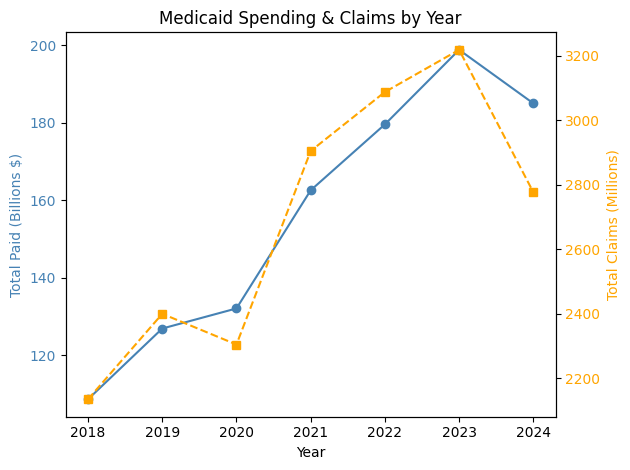

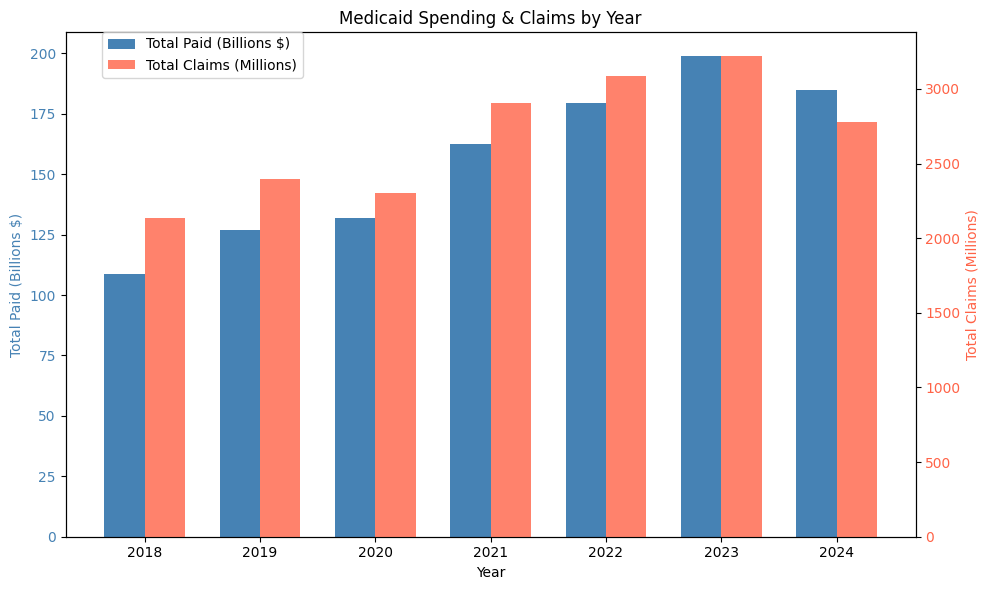

In [47]:
import matplotlib.pyplot as plt

df_yearly = con.sql("""
    SELECT
        SUBSTR(CLAIM_FROM_MONTH, 1, 4) AS year,
        SUM(TOTAL_PAID) / 1e9          AS total_paid_billions,
        SUM(TOTAL_CLAIMS) / 1e6        AS total_claims_millions   -- scale down too
    FROM medicaid
    GROUP BY year
    ORDER BY year
""").df()

fig, ax1 = plt.subplots()

# Left Y-axis — Total Paid
color1 = "steelblue"
ax1.set_xlabel("Year")
ax1.set_ylabel("Total Paid (Billions $)", color=color1)
ax1.plot(
    df_yearly["year"],
    df_yearly["total_paid_billions"],
    color=color1,
    marker="o",
    label="Total Paid",
)
ax1.tick_params(axis="y", labelcolor=color1)

# Right Y-axis — Total Claims
ax2 = ax1.twinx()
color2 = "orange"
ax2.set_ylabel("Total Claims (Millions)", color=color2)
ax2.plot(
    df_yearly["year"],
    df_yearly["total_claims_millions"],
    color=color2,
    marker="s",
    linestyle="--",
    label="Total Claims",
)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Medicaid Spending & Claims by Year")
fig.tight_layout()
plt.show()

years = df_yearly["year"]
x = np.arange(len(years))  # position of each group
width = 0.35  # width of each bar
fig, ax1 = plt.subplots(figsize=(10, 6))
# Left Y-axis — Total Paid (blue bars)
bars1 = ax1.bar(
    x - width / 2,
    df_yearly["total_paid_billions"],
    width,
    label="Total Paid (Billions $)",
    color="steelblue",
)
ax1.set_ylabel("Total Paid (Billions $)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
# Right Y-axis — Total Claims (red bars)
ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width / 2,
    df_yearly["total_claims_millions"],
    width,
    label="Total Claims (Millions)",
    color="tomato",
    alpha=0.8,
)
ax2.set_ylabel("Total Claims (Millions)", color="tomato")
ax2.tick_params(axis="y", labelcolor="tomato")
# Labels & formatting
ax1.set_xlabel("Year")
ax1.set_xticks(x)
ax1.set_xticklabels(years)
plt.title("Medicaid Spending & Claims by Year")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
fig.tight_layout()
plt.show()

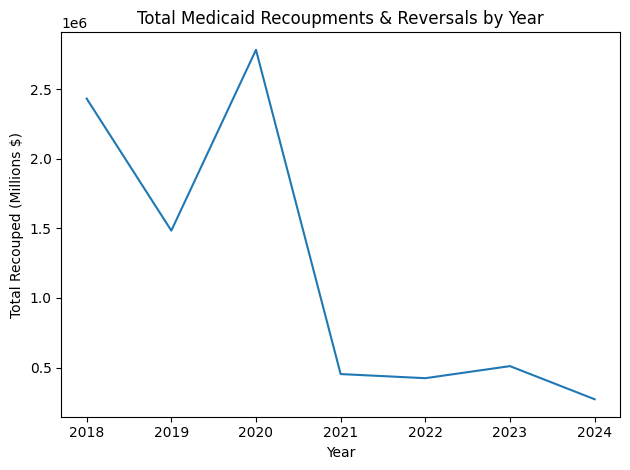

In [ ]:
df_yearly = con.sql("""
    SELECT
        SUBSTR(CLAIM_FROM_MONTH, 1, 4)       AS year,
        ABS(SUM(TOTAL_PAID))          AS total_recouped_millions
    FROM medicaid
    WHERE TOTAL_PAID < 0
    GROUP BY year
    ORDER BY year
""").df()

ax = df_yearly.plot(
    kind="line",
    x="year",
    y="total_recouped_millions",
    title="Total Medicaid Recoupments & Reversals by Year",
    legend=False,
)
ax.set_ylabel("Total Recouped (Millions $)")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()
